
# Introduction to Data Analysis with Python & Jupyter

Welcome! In this step-by-step notebook you will:

- Learn how to run code in Jupyter/Google Colab
- Use **NumPy** and **Pandas** for basic data analysis
- Create, explore, and transform a **DataFrame**
- Make your first **Matplotlib** charts

> **Tip:** In Jupyter, run the current cell with **Shift + Enter** (or ▶️ button).  
> You can add new cells with **+ Code** / **+ Text** buttons.



## What is a Jupyter Notebook?

A Jupyter Notebook mixes **explanations** (Markdown text) and **code cells** (Python).  
This makes it perfect for learning data analysis: you read a short explanation, run code,
and instantly see the output — tables, numbers, or charts.


## What is Data Pre-processing and Data Wrangling?


Before we can analyze or visualize data, we often need to **prepare** it so that it’s clean, consistent, and ready to use.

### 🔹 Data Pre-processing
Data pre-processing refers to the *initial cleaning and transformation* of raw data.  
Typical steps include:
- Converting data types (numbers, text, dates)
- Handling missing values (`NaN`, `None`)
- Renaming or standardizing column names
- Correcting inconsistent values (e.g., capitalization, typos)
- Saving cleaned datasets for future use

Think of this as “getting the data into shape” before doing anything meaningful with it.

### 🔹 Data Wrangling
Data wrangling (also called *data munging*) is the process of reshaping and transforming your dataset so it’s easy to analyze.  
This includes:
- Selecting and filtering rows or columns
- Combining datasets (merge, join)
- Grouping and aggregating values
- Creating new columns based on existing ones
- Sorting and reorganizing data

> **Example analogy:** Imagine you’re preparing ingredients before cooking a meal — you wash, peel, chop, and measure everything. Data pre-processing and wrangling do the same for your “data ingredients.”

### 🔹 Automating Pre-processing with Python
In professional settings, these preparation steps are often **automated** with Python scripts or notebooks, so the same cleaning process can run again whenever new data arrives.  
This ensures your results are consistent, reproducible, and free from manual mistakes.

**Best practices:**
- Always start with `head()`, `info()`, and `describe()` to understand the data.
- Explicitly convert data types (numeric, categorical, datetime) early.
- Keep your workflow clear — one logical step per cell.
- Save “clean” datasets separately from the original (“raw”) versions.



## 1. Setup: Import Libraries

We'll use three core libraries:

- **NumPy (`np`)** for fast numerical operations
- **Pandas (`pd`)** for working with tabular data (like Excel tables)
- **Matplotlib (`plt`)** for basic plotting

> **Best practice:** Import **once at the top** of the notebook using **standard aliases**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Optional: nicer tables and plots in notebooks
%config InlineBackend.figure_format = 'retina'
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

In [3]:
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

NumPy: 2.0.2
Pandas: 2.2.2



## 2. Create Your First DataFrame

A **DataFrame** is a 2D table with **rows** (observations) and **columns** (variables).  
Here we build one from a Python dictionary.


In [4]:
data = {
    'Name': ['Anna', 'Ben', 'Chris', 'Diana', 'Elias'],
    'Age':  [22,     25,    23,      24,      21],
    'City': ['Zurich','Bern','Luzern','Basel','Zurich']
}

In [5]:
df = pd.DataFrame(data)
df

,Name,Age,City
0,Anna,22,Zurich
1,Ben,25,Bern
2,Chris,23,Luzern
3,Diana,24,Basel
4,Elias,21,Zurich



## 3. Explore Your Data

Before analyzing, always **inspect** the data: preview rows, check structure and summary statistics.


In [6]:
# Preview the first rows
df.head()


,Name,Age,City
0,Anna,22,Zurich
1,Ben,25,Bern
2,Chris,23,Luzern
3,Diana,24,Basel
4,Elias,21,Zurich


In [7]:
# Preview the last 2 rows
df.tail(2)

,Name,Age,City
3,Diana,24,Basel
4,Elias,21,Zurich


In [8]:
# Structure: column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   City    5 non-null      object
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes



## 3.1 Missing Data (NaN / None)

Real-world datasets often contain missing values. Start by **measuring** how many there are and **decide** whether to drop or fill them.

**Steps:**
1. Inspect missing values per column with `.isnull().sum()`  
2. Option A — **Drop** rows with missing data (simple but can lose information)  
3. Option B — **Fill** (impute) missing values with a sensible statistic (e.g., median for numeric)

> **Tip:** Always report how many rows you dropped/filled, and why.


In [43]:
# Inspect missing values per column
df_miss = df.copy()
df_miss.isnull().sum()


,0
Name,0
Age,0
City,0
LanguageRegion,0
Age_next_year,0
Is_Adult,0



> **Good practice:** After imputing, quickly re-check `.describe()` and `.info()` to ensure types and ranges still make sense.



## 3.2 Detecting and Removing Duplicates

Duplicate rows can bias your analysis (e.g., double-counting).  
Use `.duplicated()` to find them and `drop_duplicates()` to remove them.

- `duplicated()` marks rows that are exact duplicates of a previous row.  
- You can also check duplicates on **specific columns** (e.g., duplicate IDs).


In [47]:
# Count duplicate rows (across all columns)
df_work = df.copy()
dup_count = df_work.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [46]:
# Show a few duplicate examples (if any)
df_work[df_work.duplicated()].head()

,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult


In [45]:
# Remove duplicate rows
#df_dedup = df_work.drop_duplicates()
#df_dedup.head()


In [14]:
# Summary statistics for numeric columns
df.describe()


,Age
count,5.000
mean,23.000
std,1.581
min,21.000
25%,22.000
50%,23.000
75%,24.000
max,25.000



> **Best practice:** Always start with `head()`, `info()`, `describe()` to catch issues early
(types, missing values, strange ranges, etc.).



## 4. Selecting Columns and Rows

Before selecting specific parts of our data, let’s clarify two key pandas objects:

### Series vs DataFrame

- A **DataFrame** is a **2D table** (rows × columns) — similar to a spreadsheet or database table.  
  Each column can store a different data type (e.g., numbers, text, dates).  
  Example: our variable `df` is a DataFrame.

- A **Series** is a **single column (or row)** of data — a one-dimensional array with an index.  
  Example: `df['Age']` returns a Series.

Think of it like this:
```
DataFrame → a collection of Series objects
Series → one column from a DataFrame
```



### Selecting Columns
- Use `df['column_name']` to select a **single column** → returns a *Series*.
- Use `df[['col1', 'col2']]` to select **multiple columns** → returns a *DataFrame*.

```python
df['City']          # One column (Series)
df[['Name', 'City']]  # Two columns (DataFrame)
```

In [15]:
# One column (returns a Series)
df['Age']


,Age
0,22
1,25
2,23
3,24
4,21


In [16]:
# Multiple columns (returns a DataFrame)
df[['Name', 'City']]


,Name,City
0,Anna,Zurich
1,Ben,Bern
2,Chris,Luzern
3,Diana,Basel
4,Elias,Zurich


> **Tip:** A Series behaves like a single column (or 1D array), while a DataFrame is a complete 2D table.  
> Operations like `.mean()` or `.plot()` on a Series affect only that one column.


### Selecting Rows
There are two main ways to select rows:

1. **Label-based selection** with `.loc[]`  
   - `.loc[]` uses the **index label** (like a row name).  
   - Example: `df.loc[0]` selects the row with index label `0`.  
   - You can also select by **conditions**, e.g.:
     ```python
     df.loc[df['Age'] > 30]  # all rows where Age > 30
     ```

2. **Position-based selection** with `.iloc[]`  
   - `.iloc[]` uses **integer position** (like array indexing).  
   - Example:  
     ```python
     df.iloc[0]      # first row
     df.iloc[:3]     # first three rows
     df.iloc[1:4, 0:2]  # rows 1–3, columns 0–1
     ```

> **Tip:**  
> - `.loc[]` is label-based — you use actual row/column names.  
> - `.iloc[]` is position-based — you use integer positions.  
> - If you mix them up, your code may return unexpected results or errors!


In [17]:
# Row by index label (here default labels are 0..n-1)
df.loc[1]


,1
Name,Ben
Age,25
City,Bern


In [18]:
# Row by integer position
df.iloc[2]


,2
Name,Chris
Age,23
City,Luzern



> **Tip:** Prefer `.loc` and `.iloc` over chained indexing (e.g., `df['col'][mask]`), which can lead to warnings.


## 5 Data Types & Simple Mapping

Real-world datasets often contain columns stored as the *wrong data type* — for example, numbers saved as text or categories stored as plain strings.  
Correct data types make analysis faster, more accurate, and memory efficient.

We’ll explore how to:
1. Inspect column data types
2. Convert (or *cast*) a column to another type using `.astype()`
3. Create a mapping from one set of values to another using `.map()`


In [19]:
# Check the current data types of each column
df.dtypes


,0
Name,object
Age,int64
City,object


**Example**: convert text column in the categorical type (saves memory and speeds up group operations)

In [20]:
df['City'] = df['City'].astype('category')
df.dtypes


,0
Name,object
Age,int64
City,category


Using `.map`: add a new column 'LanguageRegion' based on the 'City' column

In [21]:
region_map = {
    'Zurich': 'German-speaking',
    'Bern':   'German-speaking',
    'Luzern': 'German-speaking',
    'Basel':  'German-speaking'
}


In [22]:
df['LanguageRegion'] = df['City'].map(region_map)
df


,Name,Age,City,LanguageRegion
0,Anna,22,Zurich,German-speaking
1,Ben,25,Bern,German-speaking
2,Chris,23,Luzern,German-speaking
3,Diana,24,Basel,German-speaking
4,Elias,21,Zurich,German-speaking


> **Tips and Best Practices:**  
> - `astype('category')` is useful for columns that contain repeated text values — it speeds up operations and reduces memory usage.  
> - `.map(dictionary)` is great for simple one-to-one replacements, like converting city names to regions.  
> - For more complex transformations, use `.apply()` (row-by-row logic) or `np.select()` for multiple conditions.



## 6. A Quick Look at NumPy

Pandas uses NumPy **under the hood**. NumPy arrays are efficient for numeric tasks.


In [23]:
ages = np.array(df['Age'])
ages, ages.mean(), ages.std()


(array([22, 25, 23, 24, 21]), np.float64(23.0), np.float64(1.4142135623730951))


> **Tip:** Use **vectorized** operations (e.g., `ages + 1`) instead of Python loops for speed and clarity.



## 7. Adding and Modifying Columns

Create new columns based on existing data.


In [24]:
df['Age_next_year'] = df['Age'] + 1
df['Is_Adult'] = df['Age'] >= 18
df


,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult
0,Anna,22,Zurich,German-speaking,23,True
1,Ben,25,Bern,German-speaking,26,True
2,Chris,23,Luzern,German-speaking,24,True
3,Diana,24,Basel,German-speaking,25,True
4,Elias,21,Zurich,German-speaking,22,True



This code adds two new columns to the DataFrame and then displays the updated result.

1. **`df['Age_next_year'] = df['Age'] + 1`**  
   Creates a new column called **`Age_next_year`**, which represents each person’s age next year.  
   It simply adds 1 to the current value in the **`Age`** column.

2. **`df['Is_Adult'] = df['Age'] >= 18`**  
   Adds a Boolean column called **`Is_Adult`** that indicates whether each person is an adult.  
   - `True` if the person’s age is greater than or equal to 18  
   - `False` otherwise

3. **`df`**  
   Displays the updated DataFrame, now containing the new columns **`Age_next_year`** and **`Is_Adult`**.

---

**Example**

| Name  | Age | Age_next_year | Is_Adult |
|-------|-----|----------------|-----------|
| Alice | 17  | 18             | False     |
| Bob   | 22  | 23             | True      |
| Carol | 15  | 16             | False     |



> **Best practice:** When adding new columns, ensure the new Series has the **same length** as the DataFrame.



## 8. Sorting and Filtering

Sort rows by a column and filter using Boolean conditions.


In [25]:
# Sort by Age (descending)
df.sort_values(by='Age', ascending=False)


,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult
1,Ben,25,Bern,German-speaking,26,True
3,Diana,24,Basel,German-speaking,25,True
2,Chris,23,Luzern,German-speaking,24,True
0,Anna,22,Zurich,German-speaking,23,True
4,Elias,21,Zurich,German-speaking,22,True


In [26]:
# Filter: people living in Zurich
df[df['City'] == 'Zurich']


,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult
0,Anna,22,Zurich,German-speaking,23,True
4,Elias,21,Zurich,German-speaking,22,True


### Avoid using `inplace=True`

When modifying a DataFrame or Series, many pandas methods offer the parameter **`inplace=True`**, which changes the object directly instead of returning a new one.  
While this may seem convenient, it is generally **not recommended** in most cases.

- It can make your code **harder to read and debug**, since the original data is modified silently.
- It **does not improve performance** in recent versions of pandas — the difference is negligible.
- Without `inplace=True`, you can **chain operations** and **keep intermediate results** for clarity.

**Example:**

Instead of:
```python
df.drop(columns=['Age'], inplace=True)
```
Prefer:
```python
df = df.drop(columns=['Age'])
```
This makes it clear that you’re creating an updated version of the DataFrame, not silently changing the original one.


## 9. Reading Data from a CSV

Let's create a small CSV file, save it, and read it back with `pandas.read_csv`.


In [27]:
# Create and save a small CSV
tiny = pd.DataFrame({
    'product': ['notebook','pen','eraser','ruler','marker'],
    'price':   [4.5,       1.2,  0.8,      2.0,    1.5],
    'in_stock':[True,      True, False,     True,   True]
})
tiny.to_csv('tiny_store.csv', index=False)

# Read it back
tiny_loaded = pd.read_csv('tiny_store.csv')
tiny_loaded


,product,price,in_stock
0,notebook,4.5,True
1,pen,1.2,True
2,eraser,0.8,False
3,ruler,2.0,True
4,marker,1.5,True



> **Best practice:** Keep data files in a dedicated `data/` folder and use **relative paths** (e.g., `data/tiny_store.csv`).


## 10. Renaming and Standardizing Column Names

It’s good practice to ensure column names are clean and consistent.  
We’ll:
1. Work on a **copy** of the DataFrame to avoid altering earlier cells.  
2. Optionally **rename** specific columns if they have inconsistent names.  
3. Apply a **systematic cleanup** to all column names (remove spaces, lowercase, replace spaces with underscores).


In [28]:
# 1Work on a copy to avoid modifying the original DataFrame
df_clean = df.copy()


In [29]:
# Example: one-off rename (only if needed)
# Uncomment and edit if your DataFrame has inconsistent names like 'Height (m)' or 'City '
# df_clean = df_clean.rename(columns={'Height (m)': 'height_m', 'City ': 'city'})

In [30]:
# Systematic standardization of all column names
df_clean.columns = (
    df_clean.columns
        .str.strip()                                # Remove leading/trailing spaces
        .str.lower()                                # Convert to lowercase
        .str.replace(' ', '_', regex=False)         # Replace spaces with underscores
)

In [31]:
# Display the first few rows of the cleaned DataFrame
df_clean.head()

,name,age,city,languageregion,age_next_year,is_adult
0,Anna,22,Zurich,German-speaking,23,True
1,Ben,25,Bern,German-speaking,26,True
2,Chris,23,Luzern,German-speaking,24,True
3,Diana,24,Basel,German-speaking,25,True
4,Elias,21,Zurich,German-speaking,22,True



## 11. Correcting Inconsistent Values (Capitalization & Typos)

Real-world text data often contains inconsistent capitalization, trailing spaces, or occasional typos.  
Normalize values **before** grouping or merging.


In [32]:
# Normalize text values
if 'city' in df_clean.columns:
    # Fix capitalization and stray spaces
    df_clean['city'] = df_clean['city'].astype(str).str.strip().str.title()

    # Fix common typos / variants (example)
    df_clean['city'] = df_clean['city'].replace({
        'Zuerich': 'Zurich',
        'Basle': 'Basel'
    })

    # Peek unique values after cleaning
    df_clean['city'].unique()
else:
    print("Column 'city' not found in df_clean; adjust the example to your dataset.")


### Mini Task: Load → Filter → Compute

Let’s practice a simple data analysis workflow using the small dataset you just saved.

**Your task:**
1. Load the file `tiny_store.csv` (it’s already created in a previous cell).  
2. Filter the rows where the **price is greater than 1.5**.  
3. Compute the **average price** of those filtered items.  
4. *(Optional)* Plot a **histogram** of all product prices using `plt.hist()`.

> **Hint:** Try using `tiny_loaded[tiny_loaded['price'] > 1.5]` and `.mean()` for the calculation.


In [33]:

# Your solution here
filtered = tiny_loaded[tiny_loaded['price'] > 1.5]
avg_price = filtered['price'].mean()
avg_price


np.float64(3.25)


## 12. Basic Visualization with Matplotlib

Let's make a simple bar chart and a histogram.  
We'll always label axes and add a title.


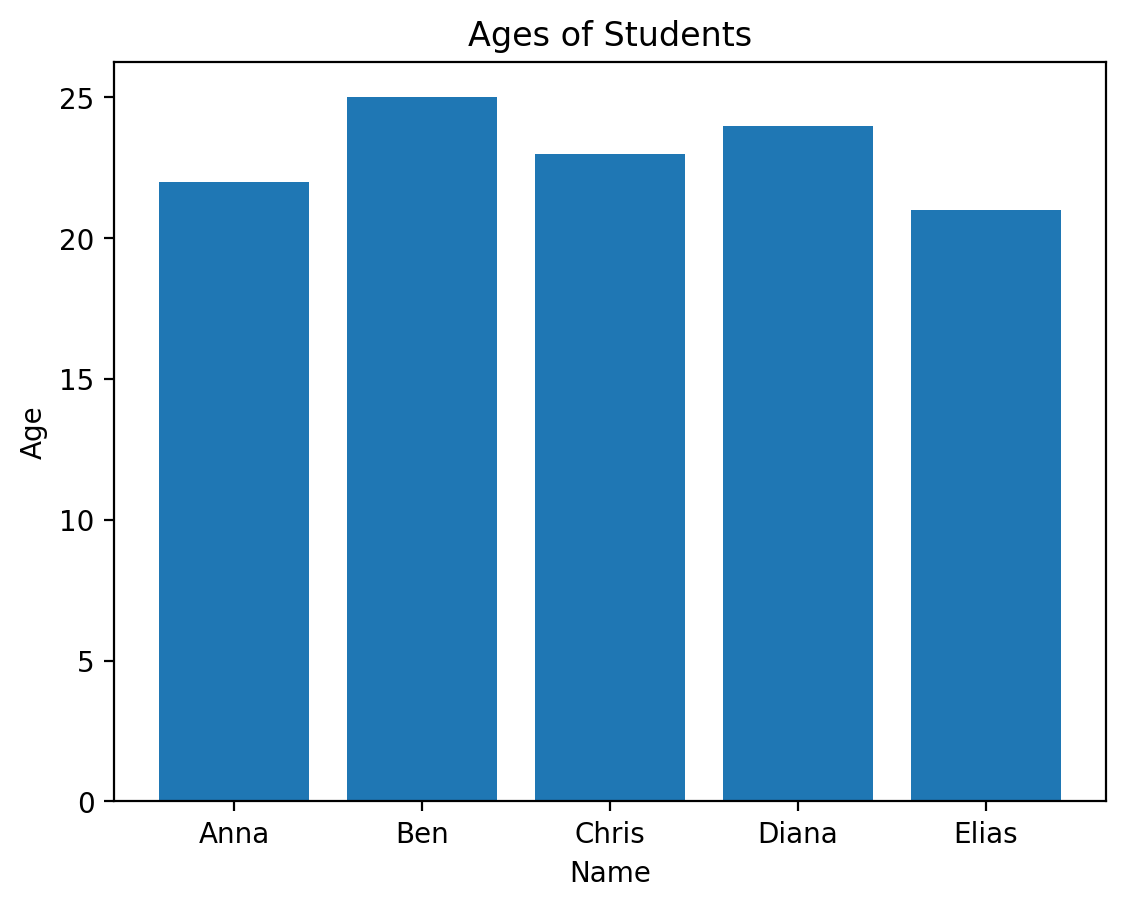

In [34]:

# Bar chart: Age by Name
plt.figure()
plt.bar(df['Name'], df['Age'])
plt.title('Ages of Students')
plt.xlabel('Name')
plt.ylabel('Age')
plt.show()


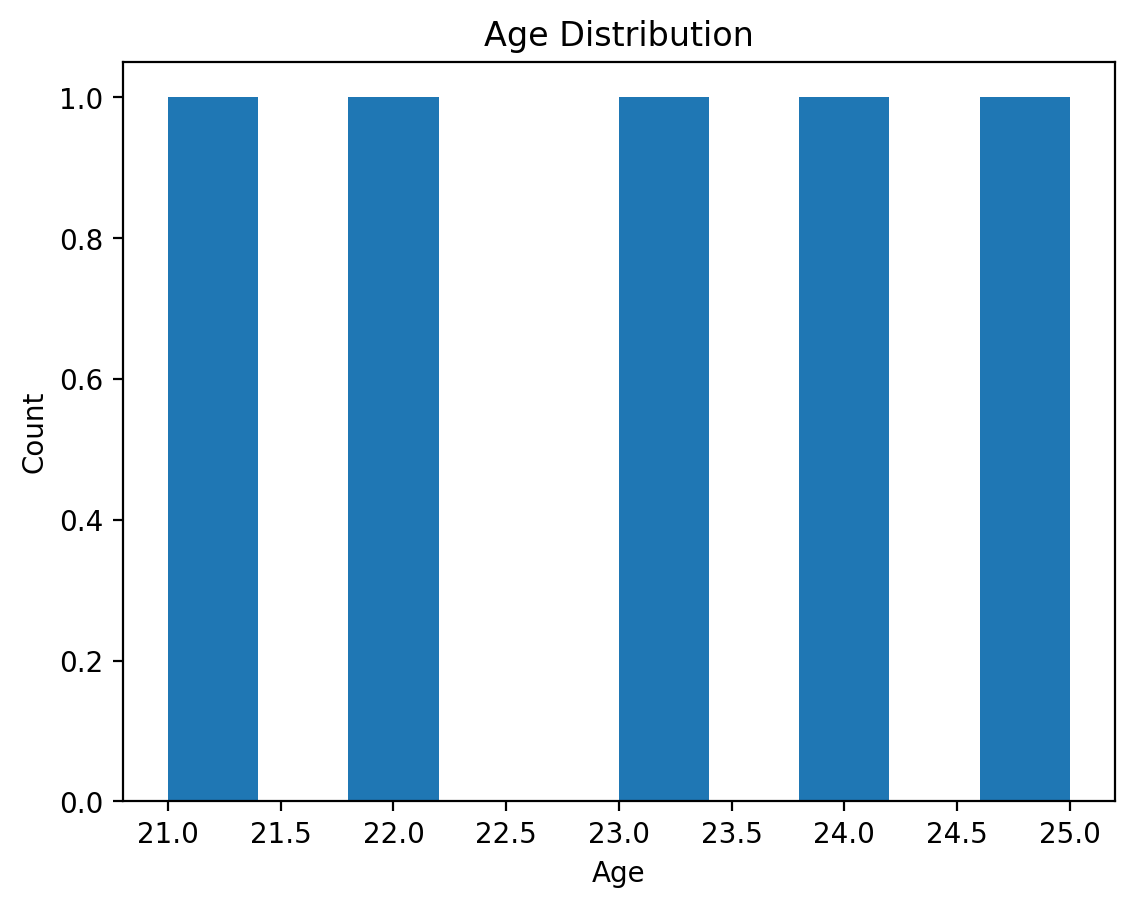

In [35]:

# Histogram: Distribution of Ages
plt.figure()
plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()



> **Tips for plots:**
> - Use clear titles and axis labels.
> - Choose an appropriate chart type (bar for categories, histogram for distributions).
> - Keep charts simple and readable; avoid heavy styling at first.



## 13. Mini Exercises (Try It Yourself)

1. **Add a new person** to the `df` DataFrame with your own details.
2. Compute the **average age** in `df`.
3. Create a new column `Name_Length` with the number of characters in each name.
4. Filter the table to show only **adults**.
5. Plot a **bar chart** of how many people live in each city.

Use the empty code cell below to work. If you need help, scroll to the **Example Solutions** section.


In [36]:

# Your work here
# Feel free to add more cells (Insert -> Insert Cell Below)




## 14. Example Solutions (Optional)

Try the exercises first — then compare with one possible solution below.


In [37]:

# 1) Add a new person (making a copy so we don't overwrite original df by mistake)
df_ex = df.copy()
new_row = {'Name': 'Fatima', 'Age': 23, 'City': 'Bern'}
df_ex.loc[len(df_ex)] = new_row
df_ex.tail()


,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult
1,Ben,25,Bern,German-speaking,26.0,1.0
2,Chris,23,Luzern,German-speaking,24.0,1.0
3,Diana,24,Basel,German-speaking,25.0,1.0
4,Elias,21,Zurich,German-speaking,22.0,1.0
5,Fatima,23,Bern,NaN,NaN,NaN


In [38]:
# 2) Average age
avg_age = df_ex['Age'].mean()
avg_age


np.float64(23.0)

In [39]:
# 3) Name length column
df_ex['Name_Length'] = df_ex['Name'].str.len()
df_ex[['Name','Name_Length']].head()


,Name,Name_Length
0,Anna,4
1,Ben,3
2,Chris,5
3,Diana,5
4,Elias,5


In [40]:
# 4) Adults only
adults = df_ex[df_ex['Is_Adult'] == True]
adults


,Name,Age,City,LanguageRegion,Age_next_year,Is_Adult,Name_Length
0,Anna,22,Zurich,German-speaking,23.0,1.0,4
1,Ben,25,Bern,German-speaking,26.0,1.0,3
2,Chris,23,Luzern,German-speaking,24.0,1.0,5
3,Diana,24,Basel,German-speaking,25.0,1.0,5
4,Elias,21,Zurich,German-speaking,22.0,1.0,5


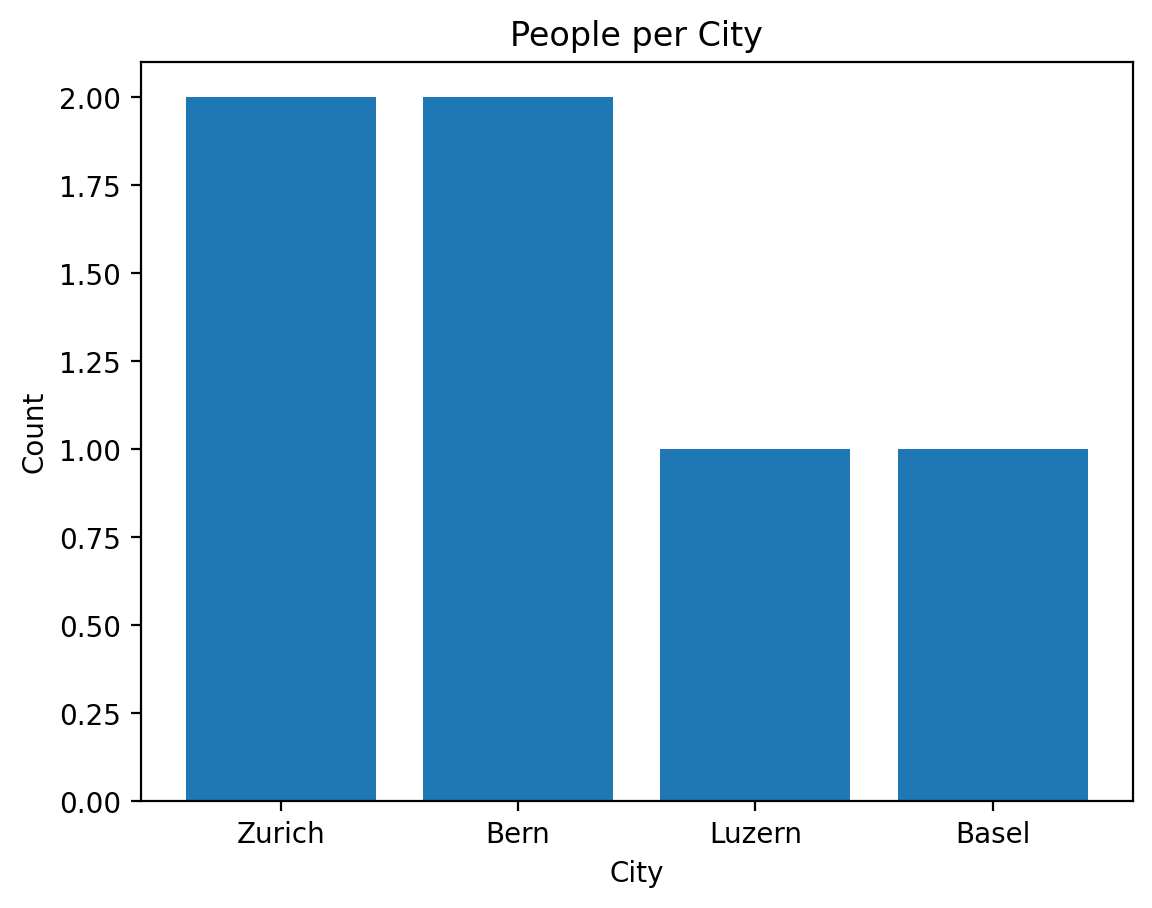

In [41]:
# 5) People per city (bar chart)
counts = df_ex['City'].value_counts()
plt.figure()
plt.bar(counts.index, counts.values)
plt.title('People per City')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()



## 15. Wrap-up & Next Steps

**What you learned:**
- How to run Python code in a notebook
- Basics of **NumPy** and **Pandas**
- Building, exploring, sorting, and filtering a DataFrame
- Saving/reading a CSV and making simple plots

**Best practices recap:**
- Start with `head()`, `info()`, `describe()`
- Use clear, vectorized operations
- Avoid `inplace=True` unless necessary
- Keep data organized in a `data/` folder
- Label plots clearly

**Coming next (Notebook 2):** Data wrangling (groupby, merge), handling missing values, and more visualizations.
